PART A: DATA PREPARATION

In [118]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [119]:
file_path = "StudentPerformanceFactors.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "lainguyn123/student-performance-factors",
  file_path,
)

C:\Users\user\AppData\Local\Temp\ipykernel_9336\571402326.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [120]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [122]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [123]:
print("=== Categorical Columns ===")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{df[col].value_counts()}")

=== Categorical Columns ===

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

Distance_from_Home
Near   

C:\Users\user\AppData\Local\Temp\ipykernel_9336\697376399.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [124]:
# Check for missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

# Check for duplicates
print("\n=== Duplicate Rows ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

=== Missing Values ===
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

=== Duplicate Rows ===
Number of duplicate rows: 0


In [125]:
# Fill Missing Values with mode for categorical columns
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

In [126]:
# Check for missing values after cleaning
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

=== Missing Values ===
No missing values found.


In [127]:
# Separate target variable and features
TARGET = "Exam_Score"

# Drop target from features
features = df.drop(columns=[TARGET])
target = df[TARGET]

print("Target variable:", TARGET)
print("Number of features:", features.shape[1])
print("Feature columns:", features.columns.tolist())

Target variable: Exam_Score
Number of features: 19
Feature columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [128]:
# Identify categorical columns
cat_cols = features.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Apply One-Hot Encoding
features_encoded = pd.get_dummies(features, columns=cat_cols, drop_first=True)

# Apply Standard Scaling
scaler = StandardScaler()
features_scaled_array = scaler.fit_transform(features_encoded)

# Convert back to DataFrame
features_final = pd.DataFrame(
    features_scaled_array, 
    columns=features_encoded.columns
)

print("New shape after encoding:", features_final.shape)
features_final.head()

Categorical columns to encode: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


C:\Users\user\AppData\Local\Temp\ipykernel_9336\3193033992.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = features.select_dtypes(include='object').columns.tolist()


New shape after encoding: (6607, 27)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,0.504942,0.348375,-0.019796,-0.143800,-1.213934,0.031411,1.985362,-1.017868,-0.498013,-1.004703,...,0.806543,0.661006,-0.803479,1.226601,-0.342867,0.997128,-0.496118,-0.658407,0.819899,0.855746
1,-0.162822,-1.383736,0.661399,-1.116110,0.411451,1.001199,1.985362,-1.017868,-0.498013,0.995319,...,0.806543,0.661006,-0.803479,-0.815261,-0.342867,-1.002880,-0.496118,1.518818,-1.219662,-1.168570
2,0.671882,1.560853,-0.019796,1.106313,0.411451,1.001199,-0.503687,0.982446,-0.498013,0.995319,...,0.806543,0.661006,1.244587,-0.815261,-0.342867,-1.002880,2.015648,-0.658407,0.819899,0.855746
3,1.506587,0.781403,0.661399,1.592469,-0.401242,1.001199,1.985362,-1.017868,-0.498013,0.995319,...,0.806543,0.661006,-0.803479,-0.815261,-0.342867,0.997128,-0.496118,1.518818,-1.219662,0.855746
4,-0.162822,1.041220,-0.700990,-0.699406,1.224144,1.001199,-0.503687,0.982446,-0.498013,0.995319,...,-1.239859,0.661006,1.244587,-0.815261,-0.342867,-1.002880,-0.496118,-0.658407,0.819899,-1.168570


In [129]:
# For Supervised Learning (Regression)
X_regression = features_final.copy()
Y_regression = target.copy()

# For Unsupervised Learning (Clustering)
X_clustering = features_final.copy() 

In [130]:
#SUPERVISED LEARNING STARTS HERE
X_regression.shape, Y_regression.shape

((6607, 27), (6607,))

In [131]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_regression, Y_regression, test_size=0.2, random_state=1)

In [132]:
X_train.shape, Y_train.shape

((5285, 27), (5285,))

In [133]:
X_test.shape, Y_test.shape

((1322, 27), (1322,))

In [134]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [135]:
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)
print("Coefficients:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)

Coefficients: [ 1.76891885  2.31832048 -0.00411365  0.7173984   0.62692315  0.1730608
 -0.79074493 -0.54576675 -0.83342491 -0.51797742  0.27118979 -0.47667459
 -0.29664875  0.22989011 -0.52796585 -0.29696731 -0.31890877 -0.27561709
  0.00429172  0.25112814  0.49657008 -0.25769467 -0.22644413  0.20559409
  0.1579352   0.43046402 -0.0160794 ]
Intercept: 67.23863451432256


In [136]:
def evaluate_model(model):
    preds = model.predict(X_test) # Predict once to save time
    print("=== Model Evaluation ===")
    print("Mean Absolute Error:", mean_absolute_error(Y_test, preds))
    print("Mean Squared Error:", mean_squared_error(Y_test, preds))
    print("R^2 Score:", r2_score(Y_test, preds))

In [137]:
evaluate_model(linear_model)

=== Model Evaluation ===
Mean Absolute Error: 0.46867590901489187
Mean Squared Error: 3.8657319065001072
R^2 Score: 0.7352044422243506


In [138]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train, Y_train)
evaluate_model(ridge_model)

=== Model Evaluation ===
Mean Absolute Error: 0.4686758153550523
Mean Squared Error: 3.865731735614455
R^2 Score: 0.7352044539297049


In [139]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train, Y_train)
evaluate_model(lasso_model)

=== Model Evaluation ===
Mean Absolute Error: 0.46829906937105104
Mean Squared Error: 3.8654750429848184
R^2 Score: 0.735222036904853


In [140]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet(alpha=0.001)
elastic_model.fit(X_train, Y_train)
evaluate_model(elastic_model)

=== Model Evaluation ===
Mean Absolute Error: 0.46824394224587146
Mean Squared Error: 3.8651552486207055
R^2 Score: 0.735243942233279


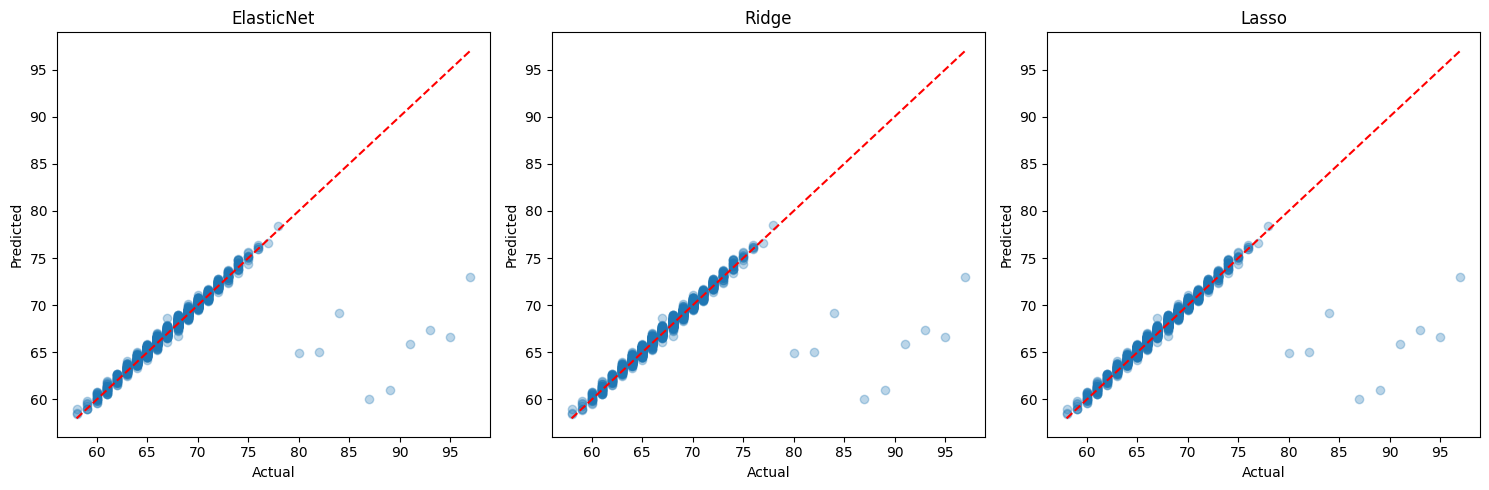

In [141]:
import matplotlib.pyplot as plt

models = {
    'ElasticNet': elastic_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    Y_pred = model.predict(X_test)
    ax.scatter(Y_test, Y_pred, alpha=0.3)
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # perfect prediction line
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(name)

plt.tight_layout()
plt.show()